# Генерация поэзии с помощью нейронных сетей: шаг 1
Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), @neychev

Ваша основная задача: научиться генерироват стихи с помощью простой рекуррентной нейронной сети (Vanilla RNN). В качестве корпуса текстов для обучения будет выступать роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина.

In [4]:
# do not change the code in the block below
# __________start of block__________
import string
import os
from random import sample

import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output

import matplotlib.pyplot as plt
# __________end of block__________

In [5]:
# do not change the code in the block below
# __________start of block__________
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('{} device is available'.format(device))
# __________end of block__________

cuda device is available


## 1. Загрузка данных.

Загрузим текст.

In [7]:
# do not change the code in the block below
# __________start of block__________
!wget https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt
    
with open('onegin.txt', 'r') as iofile:
    text = iofile.readlines()
    
text = "".join([x.replace('\t\t', '').lower() for x in text])
# __________end of block__________

--2024-11-03 10:49:41--  https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 262521 (256K) [text/plain]
Saving to: ‘onegin.txt.1’

onegin.txt.1        100%[===================>] 256.37K  --.-KB/s    in 0.1s    

2024-11-03 10:49:42 (1.82 MB/s) - ‘onegin.txt.1’ saved [262521/262521]



## 2. Построение словаря и предобработка текста
В данном задании требуется построить языковую модель на уровне символов. Приведем весь текст к нижнему регистру и построим словарь из всех символов в доступном корпусе текстов. Также добавим токен `<sos>`.

In [14]:
# do not change the code in the block below
# __________start of block__________
tokens = sorted(set(text.lower())) + ['<sos>']
num_tokens = len(tokens)

# Проверка количества токенов
assert num_tokens == 84, "Check the tokenization process"

# Сопоставление токенов их номерам и обратно
token_to_idx = {x: idx for idx, x in enumerate(tokens)}
idx_to_token = {idx: x for idx, x in enumerate(tokens)}

# Проверка уникальности и равенства сопоставлений
assert len(tokens) == len(token_to_idx), "Mapping should be unique"

print("Seems fine!")

# токенизируем текст
text_encoded = [token_to_idx[x] for x in text]
# __________end of block__________

Seems fine!


`tokens` - количество никальных токенов (символов в тесте)    
`token_to_idx` - словарь сопоставление токена его номеру    
`idx_to_token` - обратный словать сопоставления номера токена самому токену    
`text_encoded` - закодированный текст    

__Ваша задача__: обучить классическую рекуррентную нейронную сеть (Vanilla RNN) предсказывать следующий символ на полученном корпусе текстов и сгенерировать последовательность длины 100 для фиксированной начальной фразы.

Вы можете воспользоваться кодом с занятие №6 или же обратиться к следующим ссылкам:
* Замечательная статья за авторством Andrej Karpathy об использовании RNN: [link](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
* Пример char-rnn от Andrej Karpathy: [github repo](https://github.com/karpathy/char-rnn)
* Замечательный пример генерации поэзии Шекспира: [github repo](https://github.com/spro/practical-pytorch/blob/master/char-rnn-generation/char-rnn-generation.ipynb)

Данное задание является достаточно творческим. Не страшно, если поначалу оно вызывает затруднения. Последняя ссылка в списке выше может быть особенно полезна в данном случае.

Далее для вашего удобства реализована функция, которая генерирует случайный батч размера `batch_size` из строк длиной `seq_length`. Вы можете использовать его при обучении модели.

In [55]:
# do not change the code in the block below
# __________start of block__________
batch_size = 256
seq_length = 100
start_column = np.zeros((batch_size, 1), dtype=int) + token_to_idx['<sos>']

def generate_chunk():
    global text_encoded, start_column, batch_size, seq_length

    start_index = np.random.randint(0, len(text_encoded) - batch_size*seq_length - 1)
    data = np.array(text_encoded[start_index:start_index + batch_size*seq_length]).reshape((batch_size, -1))
    yield np.hstack((start_column, data))
# __________end of block__________    

Пример батча:

In [77]:
next(generate_chunk()).shape

(256, 101)

In [68]:
(next(generate_chunk())).shape
type((next(generate_chunk())))

numpy.ndarray

## 3. Обучение модели

1. Определим класс датасет чтобы использовать DataLoader а не функцию generate_chunk:

In [78]:
class TextDataset:
    def __init__(self, text_encoded, seq_length, token_to_idx):
        self.text_encoded = text_encoded
        self.seq_length = seq_length
        self.token_to_idx = token_to_idx

    def __len__(self):
        # Определяем количество возможных начал последовательностей в тексте
        return len(self.text_encoded) - self.seq_length - 1 

    def __getitem__(self, idx):
        # Генерируем случайное начало последовательности
        start_index = np.random.randint(0, len(self.text_encoded) - self.seq_length - 1)
        
        # Извлекаем последовательность заданной длины
        data = np.array(self.text_encoded[start_index:start_index + self.seq_length])
        
        # Добавляем токен начала последовательности
        start_column = np.array([self.token_to_idx['<sos>']]) 
        return np.concatenate((start_column, data))



In [79]:
dataset = TextDataset(text_encoded, seq_length, token_to_idx)

In [80]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=256, shuffle=True) 

Далее вам предстоит написать код для обучения модели и генерации текста.

In [ ]:
# your beautiful experiments here

### Определим  и инстанцируем модель

Модель имеет следующие параметры:    
`input_size` - входной размер модели, это количество возможных вариантов для каждого символа на входе RNN (равен размеру num_tokens).    
`hidden_size` -  подбирается эксперементально (выбирается в диапазоне от 32 до 512)    
`output_size` - это количество нейронов на выходном слое RNN. Каждый нейрон отвечает за вероятность появления определенного символа (равен размеру num_tokens).     
`n_layers` - количество слоёв, подбирается эксперементально (обычно от 1 до 3)    


In [81]:
from torch.autograd import Variable

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers=1):
        super(RNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers
        
        self.encoder = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, n_layers)
        self.decoder = nn.Linear(hidden_size, output_size)
    
    def forward(self, input, hidden):
        input = self.encoder(input.view(1, -1))
        output, hidden = self.gru(input.view(1, 1, -1), hidden)
        output = self.decoder(output.view(1, -1))
        return output, hidden

    def init_hidden(self):
        return Variable(torch.zeros(self.n_layers, 1, self.hidden_size))


hidden_size = 100
model = RNN(num_tokens, hidden_size, num_tokens, n_layers=1).to(device)


In [110]:
for i, batch in enumerate(dataloader):
    print(batch.shape)
    for j in range(batch.size(1) - 1):
        print(batch[j + 1, :].shape)
        break
    break

torch.Size([256, 101])
torch.Size([101])


In [112]:
# Параметры обучения
seq_length = 100
learning_rate = 0.001
n_epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Цикл обучения
for epoch in range(n_epochs):
    for i, batch in enumerate(dataloader):
        # Перемещение данных на устройство (CPU или GPU)
        batch = batch.to(device)
        
        # Инициализация скрытого состояния
        hidden = model.init_hidden().to(device)
        
        # Обнуление градиентов
        optimizer.zero_grad()
        
        # Проход вперед
        loss = 0
        
        for j in range(batch.shape[1]):
            input_seq = batch[j, :]
            target_seq = batch[j + 1, : ]

            print(input_seq.shape, target_seq.shape)

            output, hidden = model(input_seq, hidden)
            loss += criterion(output, target_seq)
        
        # Обратный проход и обновление весов
        loss.backward()
        optimizer.step()
        
        # Вывод информации о процессе обучения
        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{n_epochs}], Step [{i+1}/{len(dataloader)}], Loss: {loss.item() / (batch.size(1) - 1):.4f}")

torch.Size([101]) torch.Size([101])


RuntimeError: input.size(-1) must be equal to input_size. Expected 100, got 10100

В качестве иллюстрации ниже доступен график значений функции потерь, построенный в ходе обучения авторской сети (сам код для ее обучения вам и предстоит написать).

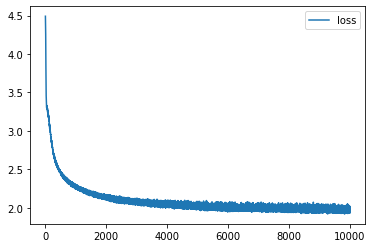

Шаблон функции `generate_sample` также доступен ниже. Вы можете как дозаполнить его, так и написать свою собственную функцию с нуля. Не забывайте, что все примеры в обучающей выборке начинались с токена `<sos>`.

In [12]:
def generate_sample(char_rnn, seed_phrase=None, max_length=200, temperature=1.0, device=device):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''
    
    if seed_phrase is not None:
        x_sequence = [token_to_idx['<sos>']] + [token_to_idx[token] for token in seed_phrase]
    else: 
        x_sequence = [token_to_idx['<sos>']]

    x_sequence = torch.tensor([x_sequence], dtype=torch.int64).to(device)
    
    #feed the seed phrase, if any
            
    # your code here
    
    return ''.join([tokens[ix] for ix in x_sequence.cpu().data.numpy()[0]])

Пример текста сгенерированного обученной моделью доступен ниже. Не страшно, что в тексте много несуществующих слов. Используемая модель очень проста: это простая классическая RNN.

In [22]:
print(generate_sample(model, ' мой дядя самых честных правил', max_length=500, temperature=0.8))

<sos> мой дядя самых честных правилас;



xiv

но как потокой.



xii

«я свобред не словавран в скорей,
для с посвялесь мне моловой,
те ты,
перегиной в тям праздной
и привезут перваю вся вновся сквозь ти стала сблился,
и старый свимарной таня обратель любова не когда и нет волностье нежной
тишен,
перестоком.
«поже постаничив очествы
в и старько забаньем и заковенью,
ее своя моднать наводушта;
какой нет поли своем горозный и быле и, законно он ходушних недважный плая
с за стра.



xvii




xxvi

все 


## Сдача задания
Сгенерируйте десять последовательностей длиной 500, используя строку ' мой дядя самых честных правил'. Температуру для генерации выберите самостоятельно на основании визуального качества генериуремого текста. Не забудьте удалить все технические токены в случае их наличия.

Сгенерированную последовательность сохрание в переменную `generated_phrase` и сдайте сгенерированный ниже файл в контест.

In [24]:
seed_phrase = ' мой дядя самых честных правил'

In [25]:
generated_phrases = # your code here

# For example:

# generated_phrases = [
#     generate_sample(
#         model,
#         ' мой дядя самых честных правил',
#         max_length=500,
#         temperature=1.
#     ).replace('<sos>', '')
#     for _ in range(10)
# ]

In [ ]:
# do not change the code in the block below
# __________start of block__________

import json
if 'generated_phrases' not in locals():
    raise ValueError("Please, save generated phrases to `generated_phrases` variable")

for phrase in generated_phrases:

    if not isinstance(phrase, str):
        raise ValueError("The generated phrase should be a string")

    if len(phrase) != 500:
        raise ValueError("The `generated_phrase` length should be equal to 500")

    assert all([x in set(tokens) for x in set(list(phrase))]), 'Unknown tokens detected, check your submission!'
    

submission_dict = {
    'token_to_idx': token_to_idx,
    'generated_phrases': generated_phrases
}

with open('submission_dict.json', 'w') as iofile:
    json.dump(submission_dict, iofile)
print('File saved to `submission_dict.json`')
# __________end of block__________

На этом задание завершено. Поздравляем!